# DeepONet for Mechanical Systems

## Learning the Solution Operator of a Dynamical System

This project investigates the use of **Deep Operator Networks (DeepONet)** to learn the solution operator of a second-order mechanical dynamical system governed by Newton's second law.

### Physical Problem

The considered system is a damped single-degree-of-freedom (SDOF) oscillator subjected to an external excitation force.

The governing equation of motion is

$$
m\ddot{x}(t) + c\dot{x}(t) + kx(t) = f(t)
$$

where:

- $m$ is the mass,
- $c$ is the damping coefficient,
- $k$ is the stiffness,
- $f(t)$ is the external excitation force,
- $x(t)$ is the displacement response.

### Objective

Unlike conventional neural networks that learn a specific solution, DeepONet aims to learn the nonlinear operator

$$
G : f(t) \mapsto x(t)
$$

which maps an input force function to its corresponding displacement response.

### DeepONet Architecture

The DeepONet model consists of two subnetworks:

- **Branch Network**: encodes the complete input force signal $f(t)$,
- **Trunk Network**: encodes the temporal coordinate $t$,
- **Latent Interaction**: combines both representations through a dot product to reconstruct the displacement response $x(t)$.

The overall objective is to approximate the operator governing the dynamical system and generalize to unseen excitation forces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from scipy.integrate import solve_ivp

In [2]:
## Model Parameters

In [146]:
np.random.seed(42)
torch.manual_seed(42)

m = 1.0     
c = 20     
k = 2e-6  

# Number of discrétisation points and time vector
num_points = 100
t = np.linspace(0, 10, num_points)

## Generation of Input Force Functions

To train a DeepONet model, it is necessary to expose the network to a diverse set of input functions.

Unlike conventional neural networks that learn a single solution, DeepONet learns an operator capable of generalizing across a family of dynamical systems responses.

For this purpose, a collection of sinusoidal excitation forces is generated:

$$
f(t)=A\sin(\omega t+\phi)
$$

where:

- $A$ is the amplitude,
- $\omega$ is the angular frequency,
- $\phi$ is the phase shift.

By varying these parameters, a family of excitation signals is obtained, producing different dynamical responses of the mechanical system.

The generated force functions constitute the input space used to train the DeepONet model and learn the mapping

$$
G:f(t)\mapsto x(t)
$$

from excitation forces to displacement responses.

In [147]:
def random_force(t):
    a1, a2, a3 = np.random.randn(3)
    force = (a1*np.sin(t) + a2*np.sin(2*t) + a3*np.sin(3*t))
    return force

## Mathematical Formulation of the Dynamical System

The governing equation of the damped mechanical oscillator is

$$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$$

To solve the system numerically using `solve_ivp`, the second-order differential equation is converted into an equivalent system of first-order ordinary differential equations.

Introducing the state variables

$$
x_1(t)=x(t)
$$

and

$$
x_2(t)=\dot{x}(t)
$$

the system can be rewritten as

$$
\frac{dx_1}{dt}=x_2
$$

and

$$
\frac{dx_2}{dt}
=
\frac{f(t)-cx_2-kx_1}{m}
$$

This first-order representation constitutes the state-space formulation used to generate the training dataset for DeepONet.

In [148]:
def oscillator(t, y, force_function):
    x, v = y
    force = force_function(t)
    dxdt = v
    dvdt = (force - c*v - k*x)/m
    return [dxdt, dvdt]

## Physical Dataset Generation

To train the DeepONet model, a dataset of input-output function pairs is generated by numerically solving the governing differential equation for multiple excitation forces.

Each sample in the dataset consists of:

- an input force function $f(t)$,
- the corresponding displacement response $x(t)$ obtained using numerical integration.

A total of $N$ different excitation functions are generated to build a diverse training dataset.

### Dataset Structure

The dataset is organized into two matrices:

#### Input Matrix

$$
\mathbf{F}
=
\begin{bmatrix}
f_1(t_1) & f_1(t_2) & \cdots & f_1(t_n) \\
f_2(t_1) & f_2(t_2) & \cdots & f_2(t_n) \\
\vdots & \vdots & \ddots & \vdots \\
f_N(t_1) & f_N(t_2) & \cdots & f_N(t_n)
\end{bmatrix}
$$

where each row represents a sampled excitation force function.

#### Output Matrix

$$
\mathbf{X}
=
\begin{bmatrix}
x_1(t_1) & x_1(t_2) & \cdots & x_1(t_n) \\
x_2(t_1) & x_2(t_2) & \cdots & x_2(t_n) \\
\vdots & \vdots & \ddots & \vdots \\
x_N(t_1) & x_N(t_2) & \cdots & x_N(t_n)
\end{bmatrix}
$$

where each row contains the displacement response associated with the corresponding excitation force.

The resulting dataset forms a collection of operator evaluations that will be used to train the DeepONet model.

In [149]:
num_functions = 200
F = np.zeros((num_functions, num_points))
X = np.zeros((num_functions, num_points))

System Solving

In [150]:
for i in range(num_functions):
    force_values = random_force(t)
    def force_function(current_t):
        return np.interp(current_t, t, force_values)
        
    # Numerical Solution
    solution = solve_ivp(
        oscillator,
        [t[0], t[-1]],
        [0, 0],                 # x(0)=0 , v(0)=0  initiales Condition
        t_eval=t,               # Evaluation Time
        args=(force_function,)
    )

    # Stockage

    F[i, :] = force_values

    # solution.y[0] = position x(t)
    X[i, :] = solution.y[0]

## Visualization of Input Force Functions

The following plot shows representative samples from the generated force dataset.

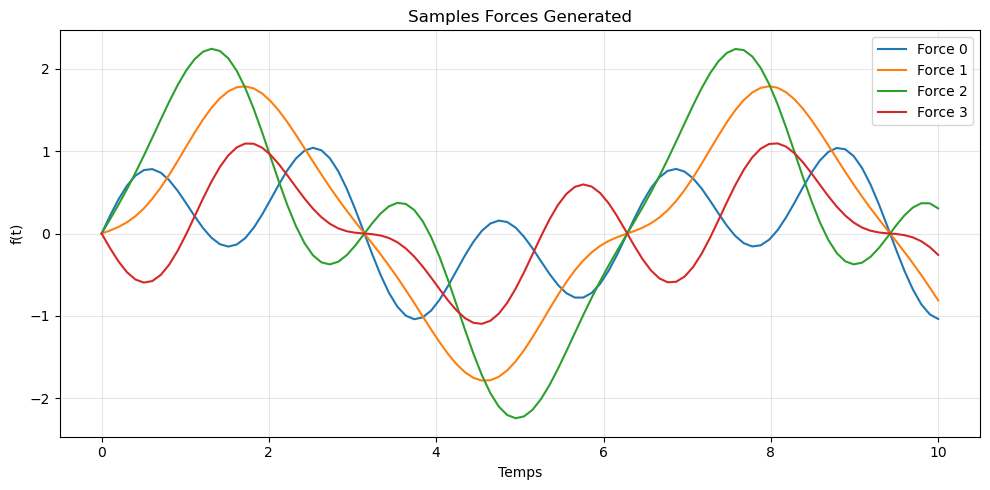

In [151]:
plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(t, F[i,:], label=f"Force {i}")
plt.title("Samples Forces Generated")
plt.xlabel("Temps")
plt.ylabel("f(t)")
plt.grid(True,which="both", alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

## Visualization of Target Responses

For each excitation force function, the governing differential equation is solved numerically to obtain the corresponding displacement response.

The resulting displacement signals constitute the target outputs used to train the DeepONet model.

The figure below presents representative samples from the generated response dataset, illustrating the diversity of dynamical behaviors induced by different excitation forces.

Together with the input force functions, these responses form the collection of input-output pairs

$$
f(t) \rightarrow x(t)
$$

used for operator learning.

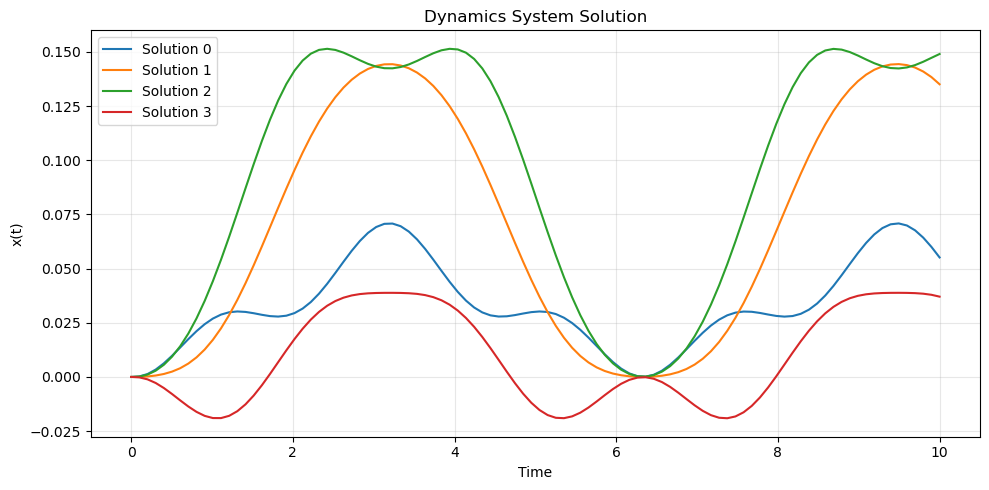

In [152]:
plt.figure(figsize=(10,5))
for i in range(4):
    plt.plot(t, X[i,:], label=f"Solution {i}")
plt.title("Dynamics System Solution")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.grid(True,which="both", alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()

## Construction of the DeepONet Dataset

The objective of DeepONet is to learn the solution operator

$$
G:f(t)\mapsto x(t)
$$

from a collection of input-output function pairs.

For each excitation force, the continuous response trajectory is sampled at multiple time instances, producing a set of training examples.

Each DeepONet sample is composed of:

$$
\big(f(t),\,t,\,x(t)\big)
$$

where:

- $f(t)$ is the complete input force function,
- $t$ is the evaluation time,
- $x(t)$ is the corresponding displacement response.

### DeepONet Inputs and Targets

The dataset is organized into three components:

#### Branch Input

$$
\mathbf{u}_s
$$

contains the discretized force functions and serves as the input to the **Branch Network**.

#### Trunk Input

$$
\mathbf{t}_s
$$

contains the temporal coordinates and serves as the input to the **Trunk Network**.

#### Target Output

$$
\mathbf{x}_s
$$

contains the displacement values corresponding to each force-time pair.

The resulting dataset enables DeepONet to learn the mapping between excitation functions and dynamical responses across the entire temporal domain.

In [153]:
def build_deeponet_dataset(F, X, t):
    num_functions = F.shape[0]
    num_points = F.shape[1]
 
    us = np.zeros((num_functions*num_points, num_points))
    ts = np.zeros((num_functions*num_points, 1))
    xs = np.zeros((num_functions*num_points, 1))
    
    for i in range(num_functions):
        for j in range(num_points):
            idx = i*num_points + j
            us[idx,:] = F[i,:]
            ts[idx,:] = t[j]
            xs[idx,:] = X[i,j]
    return us, ts, xs

Created datasets

In [154]:
us, ts, xs = build_deeponet_dataset(F, X, t)
print("Shape us :", us.shape)
print("Shape ts :", ts.shape)
print("Shape xs :", xs.shape)

Shape us : (20000, 100)
Shape ts : (20000, 1)
Shape xs : (20000, 1)


In [155]:
#SPLIT TRAIN / TEST

train_ratio = 0.9
train_size = int(len(us)*train_ratio)

#  TRAIN 

us_train = us[:train_size]
ts_train = ts[:train_size]
xs_train = xs[:train_size]

# TEST 

us_test = us[train_size:]
ts_test = ts[train_size:]
xs_test = xs[train_size:]


# CONVERSION EN TENSEURS PYTORCH
us_train = torch.tensor(us_train, dtype=torch.float32)
ts_train = torch.tensor(ts_train, dtype=torch.float32)
xs_train = torch.tensor(xs_train, dtype=torch.float32)

us_test = torch.tensor(us_test, dtype=torch.float32)
ts_test = torch.tensor(ts_test, dtype=torch.float32)
xs_test = torch.tensor(xs_test, dtype=torch.float32)

## PyTorch Dataset and DataLoader

Before training the DeepONet model, the generated data must be converted into a format compatible with the PyTorch framework.

The DeepONet dataset consists of three components:

- Branch inputs containing the discretized force functions,
- Trunk inputs containing the temporal coordinates,
- Target outputs containing the displacement responses.

A custom PyTorch Dataset is constructed to efficiently store and retrieve training samples of the form

$$
\big(\mathbf{u}_s,\mathbf{t}_s,\mathbf{x}_s\big)
$$

where:

- $\mathbf{u}_s$ represents the Branch Network input,
- $\mathbf{t}_s$ represents the Trunk Network input,
- $\mathbf{x}_s$ represents the target response.

The Dataset object is then wrapped into a PyTorch DataLoader, enabling:

- mini-batch training,
- random shuffling of samples,
- efficient memory management,
- GPU-accelerated learning.

This preprocessing step prepares the data for the optimization of the DeepONet architecture.

In [156]:
batch_size = 64
train_dataset = TensorDataset(
    us_train,
    ts_train,
    xs_train
)

test_dataset = TensorDataset(
    us_test,
    ts_test,
    xs_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

## DeepONet Architecture

### Branch Network

The Branch Network receives the discretized excitation force function as input.

Its role is to extract a latent representation of the forcing signal and encode its relevant dynamical features into a low-dimensional feature space.

Mathematically, the Branch Network computes

$$
\mathbf{b}=B(f)
$$

where:

- $f$ is the input force function,
- $B(\cdot)$ denotes the Branch Network,
- $\mathbf{b}$ is the latent representation of the excitation signal.

In [157]:
latent_dim = 64

In [158]:
class BranchNet(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

    def forward(self, u):
        return self.network(u)

### Trunk Network

The Trunk Network receives the temporal coordinate as input.

Its role is to learn a latent representation of the evaluation domain and determine how the solution evolves over time.

The Trunk Network computes

$$
\mathbf{t}=T(\tau)
$$

where:

- $\tau$ denotes the temporal coordinate,
- $T(\cdot)$ represents the Trunk Network,
- $\mathbf{t}$ is the latent representation of time.

In [159]:
# TRUNCK NET
class SinActivation(nn.Module):
    def __init__(self, omega=10.0):
        super().__init__()
        self.omega = omega

    def forward(self, x):
        return torch.sin(self.omega * x)


class TrunkNet(nn.Module):
    def __init__(self, num_time_coords=1, hidden_dim=128, latent_dim = 64, omega=10.0):
        super().__init__()

        self.network = nn.Sequential(

        nn.Linear(1, 128),

        SinActivation(),

        nn.Linear(128,128),

        SinActivation(),

        nn.Linear(128,latent_dim)
        )

    def forward(self, t):
        return self.network(t)

### Complete DeepONet Model

The final prediction is obtained by combining the latent representations produced by the Branch and Trunk Networks.

DeepONet performs a dot product between both feature vectors:

$$
x(t)=\sum_{k=1}^{p} b_k\,t_k
$$

where:

- $b_k$ are the Branch features,
- $t_k$ are the Trunk features,
- $p$ is the latent dimension.

This interaction enables the network to approximate the solution operator and predict displacement responses for previously unseen excitation forces.

In [160]:
class DeepONet(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.branch = BranchNet(input_dim, latent_dim)
        self.trunk = TrunkNet(latent_dim)
        
    def forward(self, u, t):
        # BRANCH
        branch_out = self.branch(u) 
        
        # TRUNK
        trunk_out = self.trunk(t) 
        
        # sum_k b_k(u) * t_k(x)
        
        output = torch.sum(
            branch_out * trunk_out,
            dim=1,
            keepdim=True
        )

        return output

#  CREATED MODELE

In [161]:
model = DeepONet(input_dim=num_points, latent_dim=latent_dim)

print(model)

DeepONet(
  (branch): BranchNet(
    (network): Sequential(
      (0): Linear(in_features=100, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (trunk): TrunkNet(
    (network): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SinActivation()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): SinActivation()
      (4): Linear(in_features=128, out_features=64, bias=True)
    )
  )
)


In [162]:
# LOSS & OPTIMIZER
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2.5e-4)

In [163]:
epochs = 500
train_losses = []

for epoch in range(epochs):

    model.train()
    epoch_loss = 0.0

    for u_batch, t_batch, x_batch in train_loader:

        optimizer.zero_grad()

        prediction = model(u_batch, t_batch)

        loss = loss_function(prediction, x_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    train_losses.append(epoch_loss)
    
    if epoch%50==0:
        print(f"MSE Loss {loss.item()}")

MSE Loss 0.0018264318350702524
MSE Loss 2.407235479040537e-05
MSE Loss 1.8951177480630577e-05
MSE Loss 1.4384100950337597e-06
MSE Loss 2.385400648563518e-06
MSE Loss 7.519855671489495e-07
MSE Loss 3.1189074434223585e-06
MSE Loss 6.052954631741159e-06
MSE Loss 1.0598713515719282e-06
MSE Loss 4.12943199989968e-06


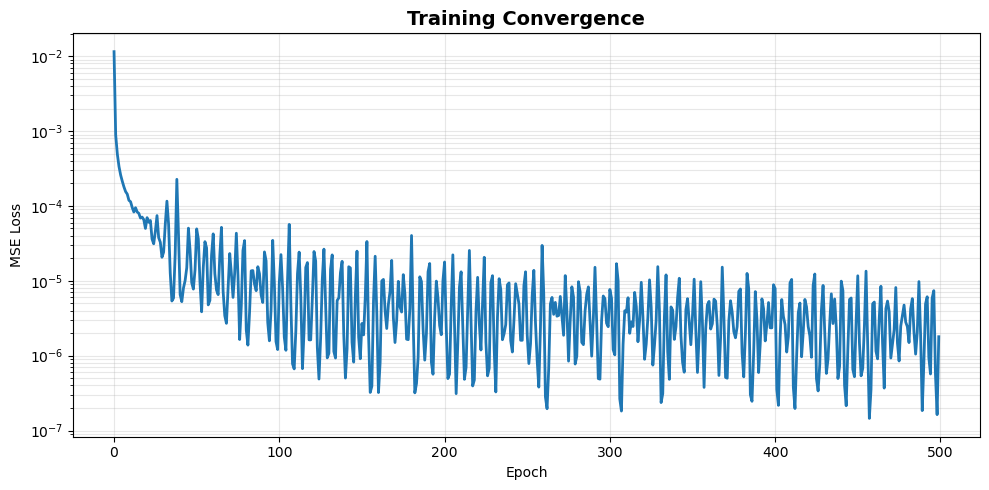

In [164]:
plt.figure(figsize=(10,5))

plt.semilogy(train_losses,linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Convergence", fontsize=14, fontweight="bold")

plt.grid(True,which="both", alpha=0.3)
plt.tight_layout()

plt.savefig("training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

## Evaluation on Test Dataset

To assess the predictive capability of the trained DeepONet, the model is evaluated on a test dataset that was not used during training.

Several performance metrics are computed, including:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Coefficient of Determination ($R^2$)

These metrics quantify the agreement between the DeepONet predictions and the numerical solutions.

In [165]:
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for u_batch, t_batch, x_batch in test_loader:

        prediction = model(u_batch, t_batch)

        all_predictions.append(prediction.cpu().numpy())

        all_targets.append(x_batch.cpu().numpy())

x_pred = np.vstack(all_predictions)
x_true = np.vstack(all_targets)

In [166]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [167]:
# Computing Metrics
mse = mean_squared_error(x_true, x_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(x_true, x_pred)

r2 = r2_score(x_true, x_pred)

print("="*40)
print("TEST DATASET PERFORMANCE")
print("="*40)
print(f"MSE  : {mse:.6e}")
print(f"RMSE : {rmse:.6e}")
print(f"MAE  : {mae:.6e}")
print(f"R²   : {r2:.6f}")
print("="*40)

TEST DATASET PERFORMANCE
MSE  : 4.505357e-06
RMSE : 2.122583e-03
MAE  : 1.612835e-03
R²   : 0.998915


In [168]:
t_plot = np.linspace(0, 10, 2000)

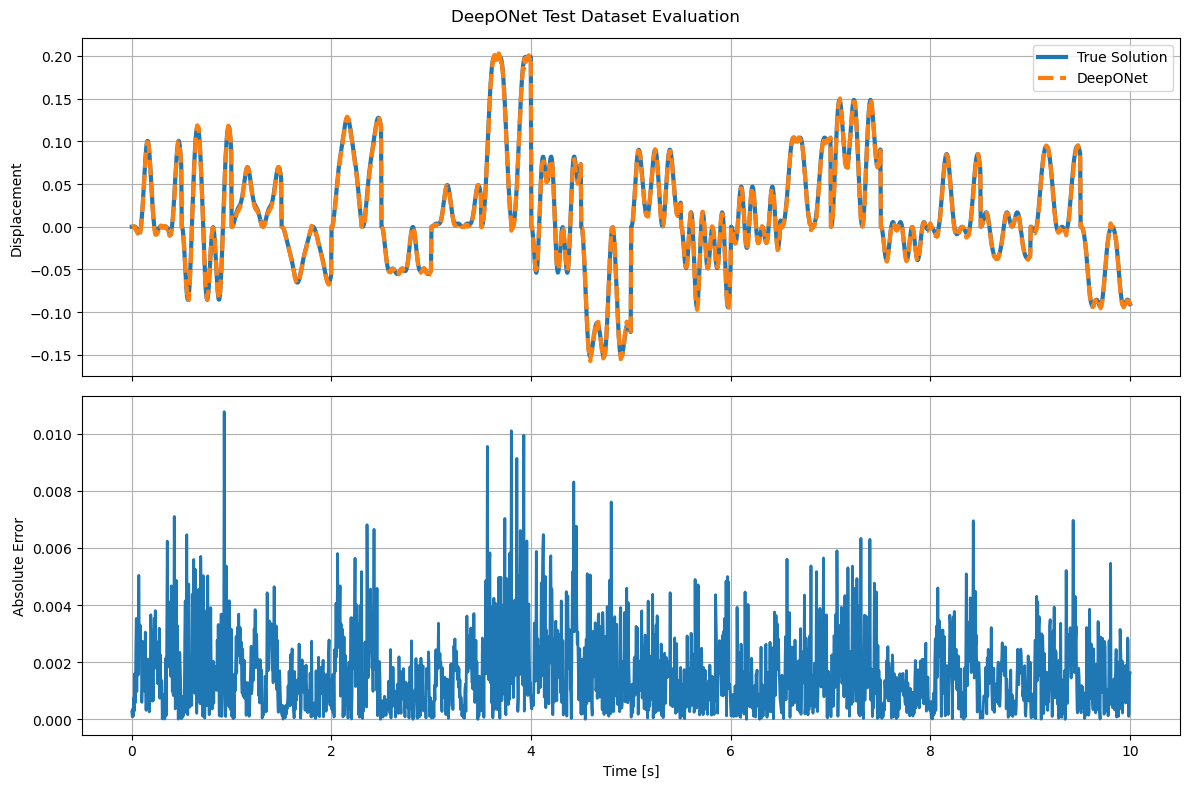

In [169]:
# Visualisation
error = np.abs(x_true.flatten() - x_pred.flatten())

fig, ax = plt.subplots(2,1,figsize=(12,8),sharex=True)

ax[0].plot(t_plot, x_true, linewidth=3, label="True Solution")
ax[0].plot(t_plot, x_pred, '--', linewidth=3, label="DeepONet")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylabel("Displacement")

ax[1].plot(t_plot, error, linewidth=2)
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Absolute Error")
ax[1].grid(True)

plt.suptitle("DeepONet Test Dataset Evaluation")

plt.tight_layout()
plt.show()

# Generalization Test on an Unseen Excitation Force

A key objective of DeepONet is not only to fit the training data, but also to generalize to previously unseen input functions.

To evaluate the operator-learning capability of the trained model, a new excitation force is generated.

This force function was **never used during training**, ensuring that the test constitutes a genuine out-of-distribution evaluation.

The trained DeepONet is then used to predict the corresponding displacement response, which is compared against the numerical solution obtained from direct integration of the governing differential equation.

The objective of this experiment is to assess the ability of DeepONet to approximate the solution operator

$$
G:f(t)\mapsto x(t)
$$

for unseen forcing conditions.

## Definition of the Test Force

A new excitation signal is generated to evaluate the predictive performance of the trained DeepONet model.

The parameters of this force differ from those used in the training dataset, providing a more rigorous assessment of the model's generalization capabilities.

In [170]:
def new_force(t):
    return (2*np.sin(t) + (3*np.sin(t)))

# CONSTRUCTION OF THE FORCE TEST
f_test = new_force(t)          

# SOLUTION EXACTE

def force_function_test(current_t):
    return np.interp(current_t, t, f_test)

solution_test = solve_ivp(oscillator, [t[0], t[-1]], [0,0], t_eval=t, args=(force_function_test,))

x_true = solution_test.y[0]

PREPARATION OF DEEPONET INPUTS DATASET TEST

In [171]:
# Branch Input
u_test = torch.tensor(f_test, dtype=torch.float32).unsqueeze(0)
u_test = u_test.repeat(len(t),1)               

# Trunck Input
t_test = torch.tensor(t, dtype=torch.float32).unsqueeze(1)

# Inference and Model Evaluation

After the training phase, the DeepONet parameters are frozen and no further optimization is performed.

The objective is now to evaluate the ability of the trained model to predict the response of a dynamical system for a previously unseen excitation force.

During inference:

- the network weights remain unchanged,
- no gradient computation is performed,
- no backpropagation is executed,
- the model is used only for prediction.

To reduce computational cost and memory usage, the evaluation is carried out within a `torch.no_grad()` context.

Given a new force function and a set of temporal coordinates, the trained DeepONet approximates the displacement response through the learned operator

$$
G:f(t)\mapsto x(t)
$$

The predicted trajectory is subsequently compared with the reference numerical solution obtained using `solve_ivp`.

This comparison provides a direct assessment of the generalization capability of the learned operator.

In [172]:
model.eval()
with torch.no_grad():
    x_pred = model(u_test, t_test)

# NUMPY CONVERSION FOR PLOTTING
x_pred = x_pred.numpy().flatten()

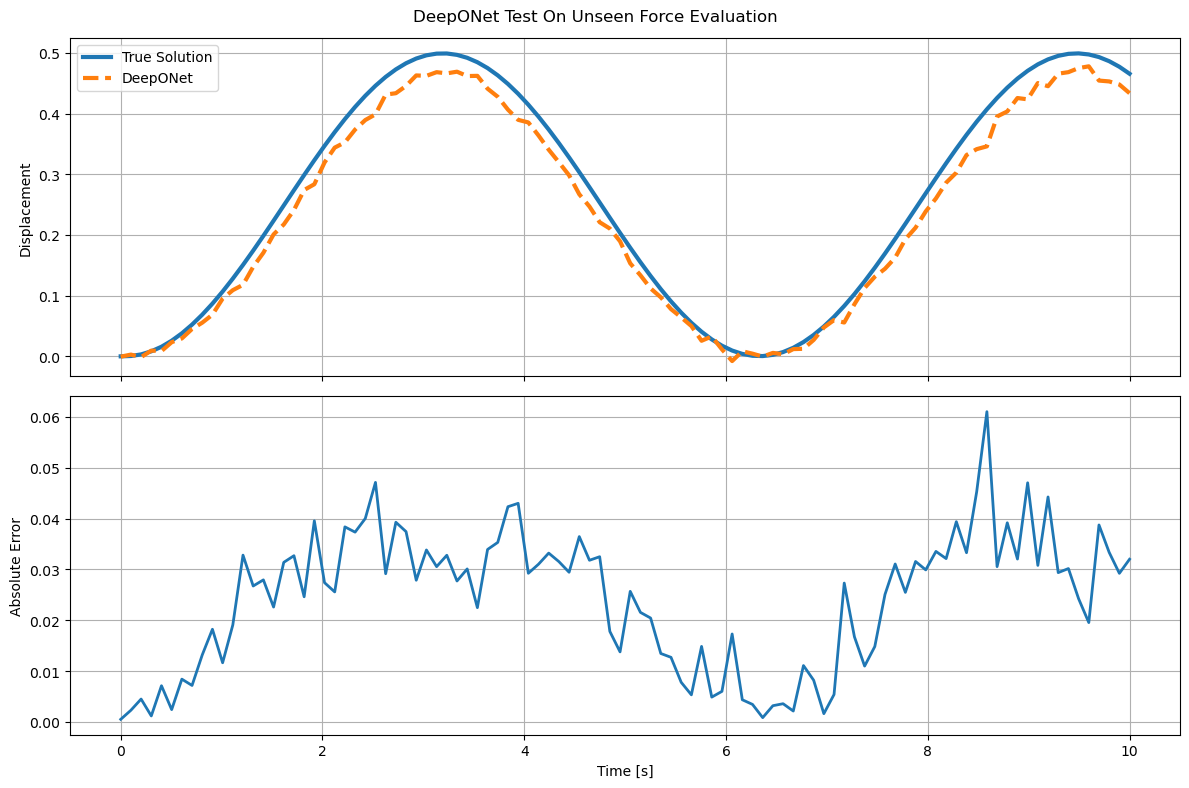

In [174]:
# Visualisation
error = np.abs(x_true.flatten() - x_pred.flatten())

fig, ax = plt.subplots(2,1,figsize=(12,8),sharex=True)

ax[0].plot(t, x_true, linewidth=3, label="True Solution")
ax[0].plot(t, x_pred, '--', linewidth=3, label="DeepONet")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylabel("Displacement")

ax[1].plot(t, error, linewidth=2)
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Absolute Error")
ax[1].grid(True)

plt.suptitle("DeepONet Test On Unseen Force Evaluation")

plt.tight_layout()
plt.show()

In [175]:
mse = mean_squared_error(x_true, x_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(x_true, x_pred)
r2 = r2_score(x_true, x_pred)

print("="*40)
print("TEST ON UNSEEN FORCE PERFORMANCE")
print("="*40)
print(f"MSE  : {mse:.6e}")
print(f"RMSE : {rmse:.6e}")
print(f"MAE  : {mae:.6e}")
print(f"R²   : {r2:.6f}")
print("="*40)

TEST ON UNSEEN FORCE PERFORMANCE
MSE  : 7.597660e-04
RMSE : 2.756385e-02
MAE  : 2.413981e-02
R²   : 0.976780
